# PENGWIN, semana 10: ajuste del modelo

Proyecto Integrador Corte 2, Analítica de Datos, UAO 2026-2. Uso exclusivamente académico.

Después de la semana 10 el modelo cumplía todo el §5 del enunciado menos la segmentación por fragmento. Este notebook reúne lo que se probó para cerrar esa brecha (unas 60 h de entrenamiento en ANTON), qué funcionó, qué no y por qué.

Contenido:

1. Punto de partida
2. Cómo medimos
3. Posproceso
4. Dónde está el error
5. Cribado de hiperparámetros (12 épocas)
6. Confirmación con 5 folds (20 épocas)
7. Ablaciones del informe: CBAM y transfer learning
8. Dropout espacial de 0 a 0,40
9. Ensamble y TTA
10. Modelo final
11. Conclusiones y siguiente paso

Todo sale de tres archivos consolidados en `reports/tuning/` (`ajuste_posproceso.csv.gz`, `ajuste_corridas.csv.gz`, `ajuste_borde.csv`), que arma `scripts/consolidar_ajuste.py` a partir de los resultados crudos de ANTON. No hace falta GPU ni el caché para correrlo.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.precision", 4)


def find_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "03_src" / "pengwin").is_dir():
            return p
    raise FileNotFoundError("No se encontró la raíz del repositorio")


ROOT = find_root()
REP = ROOT / "reports"
TUN = REP / "tuning"
FIG = REP / "figures" / "semana10_ajuste"
FIG.mkdir(parents=True, exist_ok=True)

C = {"SA": "#2a78d6", "LI": "#eb6834", "RI": "#1baf7a"}
INK, INK2, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8, "font.size": 9, "lines.linewidth": 2,
})


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")


def read_json(p):
    return json.loads(Path(p).read_text(encoding="utf-8"))


M_FRAG = ["dice_fragmento", "iou_fragmento", "dice_principal", "dice_secundario", "recuperados_secundarios_%"]
NOMBRES = {"dice_fragmento": "Dice frag", "iou_fragmento": "IoU frag", "dice_principal": "Dice principal",
           "dice_secundario": "Dice secundario", "recuperados_secundarios_%": "Secundarios %"}


# Resultados consolidados (scripts/consolidar_ajuste.py): los crudos no van a git.
PP_ALL = pd.read_csv(TUN / "ajuste_posproceso.csv.gz")
CORR = pd.read_csv(TUN / "ajuste_corridas.csv.gz")
BORDE = pd.read_csv(TUN / "ajuste_borde.csv")


def pp(nombre):
    """Barrido de posproceso de un experimento: una fila por (combinación, fold)."""
    d = PP_ALL[PP_ALL.experimento == nombre].dropna(axis=1, how="all")
    return d if len(d) else None


def historial(corrida):
    """Historial por época de un entrenamiento de CV (None si no existe)."""
    d = CORR[CORR.corrida == corrida]
    return d if len(d) else None


def borde(corrida, umbral=0.2):
    """Precisión y recall de la cabeza de borde contra edge.npy (fold 0)."""
    d = BORDE[(BORDE.corrida == corrida) & (BORDE.referencia == "edge.npy") & (BORDE.umbral == umbral)]
    return d.iloc[0] if len(d) else None


def mejor(nombre, metrica="dice_fragmento", filtro=None):
    """Combinación con la mejor media entre folds: filas por fold y sus parámetros."""
    df = pp(nombre)
    if df is None:
        return None, None
    if filtro:
        df = df.query(filtro)
    c = df.groupby("combo")[metrica].mean().idxmax()
    filas = df[df.combo == c].set_index("fold").sort_index()
    params = {k: filas.iloc[0][k] for k in ("method", "seed_depth_mm", "edge_threshold", "hmax_h_mm") if k in filas}
    return filas, params


def pareado(a, b, metrica="dice_fragmento"):
    """Diferencia emparejada por fold (a − b): media, desviación, t y folds a favor."""
    d = (a[metrica] - b[metrica]).dropna()
    n = len(d)
    sd = d.std(ddof=1) if n > 1 else np.nan
    t = d.mean() / (sd / np.sqrt(n)) if n > 1 and sd > 0 else np.nan
    return {"Δ": d.mean(), "desv Δ": sd, "t": t, "folds a favor": f"{int((d > 0).sum())}/{n}"}

## 1. Punto de partida

Modelo `v2_last` (40 épocas) con el posproceso por distancia (`edt`, semilla a 5 mm del borde). Medido una vez en test (15 pacientes).

In [2]:
ev = read_json(REP / "eval" / "v2_last_test.json")["metricas"]
fr = read_json(REP / "fragments" / "v2_last_test_edt.json")["global"]
filas = [
    ("Clasificación", "F1", ev["cls_f1_macro"], 0.85),
    ("Clasificación", "AUC", ev["cls_auc_macro"], 0.85),
    ("Detección", "IoU promedio", ev["IoU_promedio"], 0.65),
    ("Detección", "mAP@0.50", ev["mAP@0.50"], 0.65),
    ("Detección", "mAP@[.50:.95]", ev["mAP@[.50:.95]"], 0.40),
    ("Segmentación de fragmento", "Dice", fr["dice_fragmento"], 0.85),
    ("Segmentación de fragmento", "IoU", fr["iou_fragmento"], 0.70),
]
inicio = pd.DataFrame(filas, columns=["Tarea", "Métrica", "Test", "Objetivo"])
inicio["Cumple"] = np.where(inicio.Test >= inicio.Objetivo, "sí", "no")
inicio["Falta"] = (inicio.Objetivo - inicio.Test).clip(lower=0)
inicio.round(3)

,Tarea,Métrica,Test,Objetivo,Cumple,Falta
0,Clasificación,F1,0.993,0.85,sí,0.000
1,Clasificación,AUC,0.999,0.85,sí,0.000
2,Detección,IoU promedio,0.919,0.65,sí,0.000
3,Detección,mAP@0.50,0.980,0.65,sí,0.000
4,Detección,mAP@[.50:.95],0.864,0.40,sí,0.000
5,Segmentación de fragmento,Dice,0.725,0.85,no,0.125
6,Segmentación de fragmento,IoU,0.671,0.70,no,0.029


Detección y clasificación sobran. Lo que falta es la segmentación por **fragmento**: 0,125 de Dice y 0,029 de IoU.

El Dice por fragmento se calcula sobre cada fragmento real: se empareja con el predicho que más se le parece, y si no tiene pareja cuenta como 0. Por eso pesa tanto un fragmento pequeño que no se detecta.

## 2. Cómo medimos

Reglas que se fijaron antes de empezar, para no engañarnos con las métricas:

- **El test no se usa para elegir nada.** Solo se mide al final, una vez.
- **Validación cruzada por paciente:** los 85 casos de train+val en 5 folds de 17 pacientes. Cada modelo predice los pacientes que no vio en su entrenamiento (predicciones *fuera de fold*), y sobre esas predicciones se ajusta el posproceso sin reentrenar.
- **Comparaciones emparejadas por fold:** cada candidato contra la referencia en los mismos pacientes.
- **Ruido de semilla:** entrenamos la misma configuración con semillas distintas. Una diferencia más chica que ese ruido no cuenta como mejora.

Primero el ruido. Cuatro entrenamientos idénticos (12 épocas, fold 0) que solo cambian la semilla:

In [3]:
semillas = {}
for nombre, s in (("cv_c00_base_e12_f0", 42), ("cv_c00b_seed1337_e12_f0", 1337),
                  ("cv_c00c_seed2024_e12_f0", 2024), ("cv_c00c_seed7_e12_f0", 7)):
    f, p = mejor(f"pp_scr_{nombre}")
    semillas[s] = {**{NOMBRES[m]: f[m].iloc[0] for m in M_FRAG[:2]}, "profundidad óptima (mm)": p["seed_depth_mm"]}
semillas = pd.DataFrame(semillas).T
semillas.index.name = "semilla"
SIGMA12 = semillas["Dice frag"].std(ddof=1)
display(semillas.round(4))
print(f"σ entre semillas (Dice por fragmento, 12 épocas, 1 fold): {SIGMA12:.4f}  ->  umbral 2σ = {2 * SIGMA12:.4f}")

,Dice frag,IoU frag,profundidad óptima (mm)
semilla,,,
42,0.6925,0.6296,4.0
1337,0.6700,0.5914,6.0
2024,0.6770,0.6052,6.0
7,0.6746,0.5981,6.0


σ entre semillas (Dice por fragmento, 12 épocas, 1 fold): 0.0097  ->  umbral 2σ = 0.0195


Solo cambiando la semilla, el Dice por fragmento se mueve 0,0225 entre la mejor y la peor corrida. Ese es el tamaño del ruido contra el que se compara todo lo demás.

A 20 épocas y con 5 folds emparejados se midió igual: la misma configuración con semilla 1337 contra la de semilla 42 da Δ medio 0,000 con desviación por fold de 0,013.

## 3. Posproceso

El posproceso parte cada hueso en fragmentos. Dos parámetros importan: la **profundidad de semilla** (a cuántos mm del borde empieza un fragmento) y el **umbral de borde** (desde qué probabilidad un píxel cuenta como borde de fractura). Se barrieron sobre las predicciones fuera de fold del modelo base (20 épocas, 5 folds):

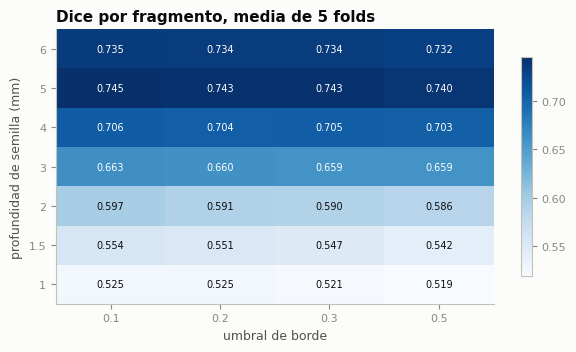

,solo borde (edge),distancia (edt)
Dice frag,0.498,0.745
IoU frag,0.460,0.683
Dice principal,0.909,0.921
Dice secundario,0.052,0.556
Secundarios %,4.923,59.510


In [4]:
b = pp("pp1_base_e20").query("method == 'edt'")
mapa = b.groupby(["seed_depth_mm", "edge_threshold"]).dice_fragmento.mean().unstack()
fig, ax = plt.subplots(figsize=(6.2, 3.6))
im = ax.imshow(mapa.values, cmap="Blues", aspect="auto", origin="lower")
ax.set_xticks(range(mapa.shape[1]), [f"{x:g}" for x in mapa.columns])
ax.set_yticks(range(mapa.shape[0]), [f"{y:g}" for y in mapa.index])
ax.set(xlabel="umbral de borde", ylabel="profundidad de semilla (mm)")
ax.set_title("Dice por fragmento, media de 5 folds", loc="left")
ax.grid(False)
for i in range(mapa.shape[0]):
    for j in range(mapa.shape[1]):
        v = mapa.values[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7, color="white" if v > mapa.values.mean() else INK)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
savefig(fig, "01_posproceso_mapa")
plt.show()

edge, _ = mejor("pp1_base_e20_edge")
edt, _ = mejor("pp1_base_e20")
pd.DataFrame({"solo borde (edge)": edge[M_FRAG].mean(), "distancia (edt)": edt[M_FRAG].mean()}).rename(index=NOMBRES).round(3)

- El mejor valor está en 5 mm, que es el que ya usábamos. Las combinaciones vecinas quedan a menos de 0,003, muy por debajo del ruido entre folds.
- El umbral de borde casi no cambia nada (columnas casi iguales). Es una pista: el borde predicho casi nunca pasa de 0,1, así que da igual dónde se corte.
- Separar por distancia (`edt`) en vez de solo por borde vale +0,245 de Dice. Es la mejora más grande del proyecto, y ya estaba en el modelo de la semana 10.

El posproceso estaba bien elegido; no queda ganancia ahí.

## 4. Dónde está el error

Para saber qué parte del modelo frena el Dice, se cambiaron por el ground truth, por separado, sus dos salidas: la **región** (qué hueso es cada píxel) y el **borde de fractura**.

,Dice frag,IoU frag,Dice principal,Dice secundario,Secundarios %,profundidad (mm)
modelo real,0.745,0.683,0.921,0.556,59.510,5.0
región real + borde predicho,0.770,0.729,0.947,0.578,59.572,5.0
región predicha + borde real,0.902,0.856,0.958,0.841,90.586,3.0
región real + borde real,0.989,0.984,0.999,0.979,99.100,2.0


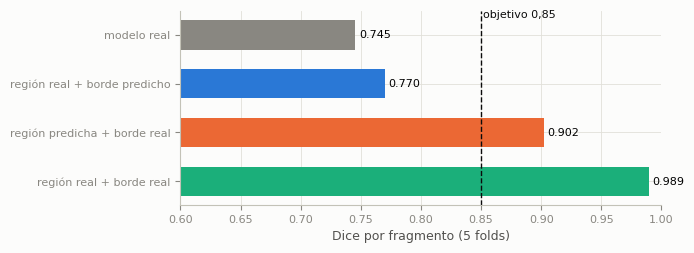

In [5]:
casos = {
    "modelo real": "pp1_base_e20",
    "región real + borde predicho": "pp_hib_gtsem_prededge",
    "región predicha + borde real": "pp_hib_predsem_gtedge",
    "región real + borde real": "pp_oraculo_gt",
}
filas = {}
for k, n in casos.items():
    f, p = mejor(n)
    filas[k] = {**{NOMBRES[m]: f[m].mean() for m in M_FRAG}, "profundidad (mm)": p["seed_depth_mm"]}
hib = pd.DataFrame(filas).T
display(hib.round(3))

fig, ax = plt.subplots(figsize=(7, 2.6))
y = np.arange(len(hib))[::-1]
ax.barh(y, hib["Dice frag"], color=[MUTED, C["SA"], C["LI"], C["RI"]], height=0.6)
ax.axvline(0.85, color=INK, ls="--", lw=1)
ax.text(0.852, y[0] + 0.35, "objetivo 0,85", fontsize=8, color=INK)
ax.set_yticks(y, hib.index)
ax.set_xlim(0.6, 1.0)
ax.set_xlabel("Dice por fragmento (5 folds)")
for yi, v in zip(y, hib["Dice frag"]):
    ax.text(v + 0.003, yi, f"{v:.3f}", va="center", fontsize=8)
fig.tight_layout()
savefig(fig, "02_donde_esta_el_error")
plt.show()

In [6]:
BORDE.query("corrida == 'cv_c00_base_e12_f0' and referencia == 'edge.npy'").set_index("umbral")[["precision", "recall"]].round(3)

,precision,recall
umbral,,
0.1,0.344,0.177
0.2,0.352,0.164
0.3,0.358,0.156
0.5,0.368,0.144


- Con el **borde real**, el Dice sube de 0,743 a 0,902 (+0,159). Con la **región real**, apenas +0,027. El problema es la cabeza de borde, seis veces más que la región.
- La cabeza de borde encuentra **menos del 20 %** de la superficie de fractura real (recall), y bajar el umbral casi no lo sube: el resto no está "casi detectado", está en cero.
- Con el borde real ya se pasaría el 0,85. Todo lo que sigue intenta mejorar ese borde.

## 5. Cribado de hiperparámetros (12 épocas)

Once cambios de entrenamiento, cada uno contra la referencia, todos con 12 épocas en el fold 0. A cada uno se le buscó su mejor posproceso, igual que a las semillas.

,Dice frag,Δ,IoU frag,Secundarios %,precisión borde,recall borde,Δ/σ,cambio
c05_oversample3,0.7031,0.0106,0.6447,52.7273,0.4544,0.1866,1.0854,repetir ×3 cortes con fragmentos secundarios
c06_lr1e3,0.6963,0.0038,0.6197,52.7273,0.3988,0.1711,0.3890,lr 1e-3 (base 3e-4)
c03_edge_d1,0.6939,0.0014,0.6320,52.7273,0.3908,0.1152,0.1434,borde más fino (dilatación 1)
c00_base,0.6925,0.0000,0.6296,47.2727,0.3522,0.1643,0.0000,referencia (semilla 42)
c01_posw4,0.6908,-0.0017,0.6270,47.2727,0.3652,0.1571,-0.1693,peso del borde 4 (base 9)
c08_sdrop02,0.6905,-0.0020,0.6294,50.9091,0.3233,0.1844,-0.2066,"dropout espacial 0,2 (base 0,1)"
c07_sdrop0,0.6891,-0.0034,0.6222,50.9091,0.4098,0.1650,-0.3460,sin dropout espacial
c04_edge_d3,0.6875,-0.0049,0.6247,49.0909,0.3047,0.1882,-0.5078,borde más grueso (dilatación 3)
c02_posw16,0.6835,-0.0090,0.6217,45.4545,0.3436,0.1532,-0.9245,peso del borde 16
c09_augstrong,0.6805,-0.0120,0.6182,49.0909,0.3179,0.1868,-1.2330,aumentación fuerte


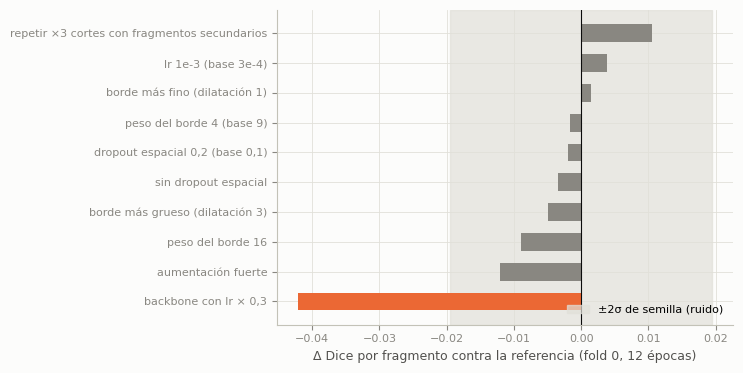

In [7]:
CANDIDATOS = {
    "c00_base": "referencia (semilla 42)",
    "c01_posw4": "peso del borde 4 (base 9)",
    "c02_posw16": "peso del borde 16",
    "c03_edge_d1": "borde más fino (dilatación 1)",
    "c04_edge_d3": "borde más grueso (dilatación 3)",
    "c05_oversample3": "repetir ×3 cortes con fragmentos secundarios",
    "c06_lr1e3": "lr 1e-3 (base 3e-4)",
    "c07_sdrop0": "sin dropout espacial",
    "c08_sdrop02": "dropout espacial 0,2 (base 0,1)",
    "c09_augstrong": "aumentación fuerte",
    "c10_bblr03": "backbone con lr × 0,3",
}
ref, _ = mejor("pp_scr_cv_c00_base_e12_f0")
filas = {}
for c, desc in CANDIDATOS.items():
    f, p = mejor(f"pp_scr_cv_{c}_e12_f0")
    rb = borde(f"cv_{c}_e12_f0")
    rb = {} if rb is None else rb.to_dict()
    filas[c] = {"cambio": desc, "Dice frag": f.dice_fragmento.iloc[0], "Δ": f.dice_fragmento.iloc[0] - ref.dice_fragmento.iloc[0],
                "IoU frag": f.iou_fragmento.iloc[0], "Secundarios %": f["recuperados_secundarios_%"].iloc[0],
                "precisión borde": rb.get("precision"), "recall borde": rb.get("recall")}
crib = pd.DataFrame(filas).T
crib["Δ/σ"] = crib["Δ"].astype(float) / SIGMA12
crib = crib.sort_values("Dice frag", ascending=False)
display(crib.drop(columns="cambio").astype(float).round(4).join(crib.cambio))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
d = crib.drop("c00_base")["Δ"].astype(float)[::-1]
ax.axvspan(-2 * SIGMA12, 2 * SIGMA12, color=GRID, alpha=0.7, label="±2σ de semilla (ruido)")
ax.barh(range(len(d)), d, color=[C["RI"] if v > 2 * SIGMA12 else (C["LI"] if v < -2 * SIGMA12 else MUTED) for v in d], height=0.6)
ax.set_yticks(range(len(d)), [CANDIDATOS[i] for i in d.index])
ax.axvline(0, color=INK, lw=0.8)
ax.set_xlabel("Δ Dice por fragmento contra la referencia (fold 0, 12 épocas)")
ax.legend(loc="lower right")
fig.tight_layout()
savefig(fig, "03_cribado")
plt.show()

- Diez de los once caen dentro de la banda de ruido: lo que se ve entre ellos es la semilla, no el cambio.
- El único efecto claro es **negativo**: frenar el backbone preentrenado (lr × 0,3) baja 0,042. El backbone necesita adaptarse por completo.
- El mejor fue `c05` (repetir los cortes con secundarios), +0,011, que todavía es ruido. Pasó a confirmarse con 5 folds.

## 6. Confirmación con 5 folds (20 épocas)

Aquí se compara con más poder: 5 folds emparejados, 20 épocas. Además de hiperparámetros se probaron cambios de **arquitectura** dentro de lo que permite el enunciado:

- **Núcleo/borde (F2B1):** en vez de un mapa de borde, la cabeza predice 3 clases (fondo, núcleo, borde), como el ganador de PENGWIN 2024.
- **Mapa de distancia (F2B2):** la cabeza predice a cuántos mm está cada píxel de la fractura.
- **Semillas por h-máxima (F2C1, F2C2):** cambios solo de posproceso para no perder fragmentos pequeños.

Los modelos con otra semilla (1337) se comparan contra la referencia de semilla 1337.

In [8]:
# (nombre, archivo, referencia, filtro del candidato, filtro de la referencia)
# F2C2 cambia solo el posproceso: se compara contra edt con la MISMA profundidad y umbral, para aislar el método.
IGUAL = "method == 'edt' and seed_depth_mm == 5 and edge_threshold == 0.1"
EXP = [
    ("Control: misma config, semilla 1337", "pp1_c00b_seed1337_e20", "pp1_base_e20", None, None),
    ("c05 repetir cortes con secundarios", "pp1_c05_oversample3_e20", "pp1_base_e20", None, None),
    ("Sin transfer learning (semilla 42)", "pp_f2a_sintl", "pp1_base_e20", None, None),
    ("Sin transfer learning (semilla 1337)", "pp_f2a_s1337", "pp1_c00b_seed1337_e20", None, None),
    ("Sin CBAM", "pp_abl_nocbam", "pp1_base_e20", None, None),
    ("F2B1 núcleo/borde, su método", "pp_f2b1_core3", "pp1_base_e20", None, None),
    ("F2B1, mismo modelo con posproceso edt", "pp_f2b1_con_edt", "pp1_base_e20", None, None),
    ("F2B2 mapa de distancia, su método", "pp_f2b2_dist", "pp1_base_e20", None, None),
    ("F2B2, mismo modelo con posproceso edt", "pp_f2b2_con_edt", "pp1_base_e20", None, None),
    ("F2C1 semillas h-máxima", "pp_hmax_base_e20", "pp1_base_e20", None, None),
    ("F2C2 edt + h-máxima (semilla 42)", "pp_edthmax_base_e20", "pp1_base_e20", "hmax_h_mm == 1.0 and seed_depth_mm == 5", IGUAL),
    ("F2C2 con h = 1,5 (semilla 42)", "pp_edthmax_base_e20", "pp1_base_e20", "hmax_h_mm == 1.5 and seed_depth_mm == 5", IGUAL),
    ("F2C2 edt + h-máxima (semilla 1337)", "pp_edthmax_rep1337", "pp1_c00b_seed1337_e20", "hmax_h_mm == 1.0", IGUAL),
    ("F2C2 con h = 1,5 (semilla 1337)", "pp_edthmax_rep1337", "pp1_c00b_seed1337_e20", "hmax_h_mm == 1.5", IGUAL),
]
base_f, _ = mejor("pp1_base_e20")
filas, PF = {}, {}
for nombre, arch, refn, filtro, rfiltro in EXP:
    f, _ = mejor(arch, filtro=filtro)
    if f is None:
        continue
    r, _ = mejor(refn, filtro=rfiltro)
    pr = pareado(f, r)
    PF[nombre] = (f.dice_fragmento - r.dice_fragmento)
    filas[nombre] = {"Dice frag": f.dice_fragmento.mean(), "IoU frag": f.iou_fragmento.mean(),
                     "Dice principal": f.dice_principal.mean(), "Secundarios %": f["recuperados_secundarios_%"].mean(),
                     "Δ Dice": pr["Δ"], "t": pr["t"], "folds a favor": pr["folds a favor"],
                     "Δ IoU": pareado(f, r, "iou_fragmento")["Δ"], "Δ principal": pareado(f, r, "dice_principal")["Δ"]}
conf = pd.DataFrame(filas).T
ref_row = pd.DataFrame({"Dice frag": base_f.dice_fragmento.mean(), "IoU frag": base_f.iou_fragmento.mean(),
                        "Dice principal": base_f.dice_principal.mean(),
                        "Secundarios %": base_f["recuperados_secundarios_%"].mean()}, index=["Referencia (base, semilla 42)"])
display(pd.concat([ref_row, conf]).round(4).fillna(""))

,Dice frag,IoU frag,Dice principal,Secundarios %,Δ Dice,t,folds a favor,Δ IoU,Δ principal
"Referencia (base, semilla 42)",0.7453,0.6828,0.9206,59.5101,,,,,
"Control: misma config, semilla 1337",0.7446,0.6687,0.8973,58.9398,-0.0007,-0.1182,3/5,-0.0142,-0.0233
c05 repetir cortes con secundarios,0.7540,0.6939,0.9242,62.3802,0.0087,0.943,3/5,0.011,0.0035
Sin transfer learning (semilla 42),0.7594,0.6969,0.9245,62.7773,0.0141,1.0396,3/5,0.014,0.0039
Sin transfer learning (semilla 1337),0.7522,0.6903,0.9242,60.8949,0.0076,0.6003,3/5,0.0216,0.0269
Sin CBAM,0.7365,0.6744,0.9197,56.3262,-0.0088,-0.9245,1/5,-0.0085,-0.0009
"F2B1 núcleo/borde, su método",0.6729,0.6253,0.9255,41.2824,-0.0724,-3.1253,1/5,-0.0575,0.0049
"F2B1, mismo modelo con posproceso edt",0.7461,0.6737,0.9023,58.3526,0.0008,0.0993,3/5,-0.0091,-0.0183
"F2B2 mapa de distancia, su método",0.5039,0.4680,0.9151,5.7422,-0.2414,-10.8826,0/5,-0.2148,-0.0055
"F2B2, mismo modelo con posproceso edt",0.7298,0.6686,0.9146,53.6832,-0.0155,-1.0735,1/5,-0.0143,-0.0061


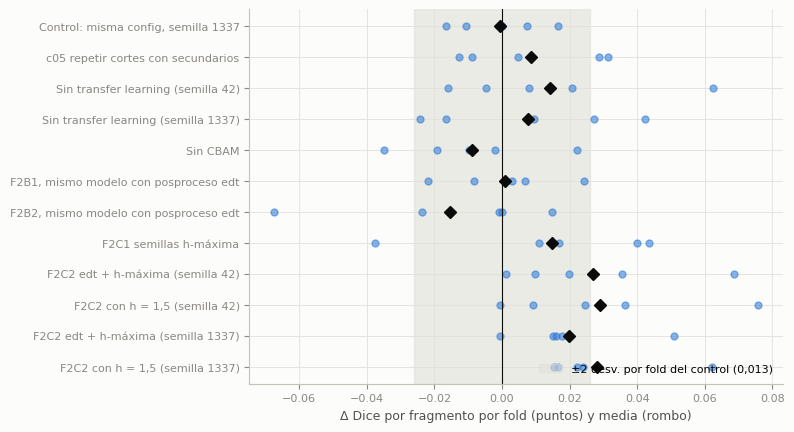

,mAP50,mAP5095,iou_caja,F1,AUC,decision
id,,,,,,
P1-base,0.9785,0.8438,0.9111,0.9905,0.9987,referencia
P4-c05,0.9812,0.8718,0.9217,0.9926,0.9990,"NO se adopta: 1.60 sigma, 3/5 folds"
P4-ctrl,0.9772,0.8362,0.9079,0.9896,0.9984,control: sigma por fold 0.0130
F2A,0.9767,0.8312,0.9059,0.9881,0.9975,no confirma con la replica (ver F2A-rep): NO s...
F2B1,0.9791,0.8587,0.9168,0.9917,0.9989,RECHAZADO: -0.072 vs base
F2B1-ctrl,0.9791,0.8587,0.9168,0.9917,0.9989,"control: el modelo es igual al base (+0.0005),..."
F2A-rep,0.9771,0.8254,0.9040,0.9900,0.9984,"no confirma: agrupado t=1.19, 6/10 folds -> LI..."
F2B2,0.9823,0.8925,0.9301,0.9934,0.9992,"RECHAZADO: 0.5039, rec 5.7%, plano en todos lo..."
F2B2-ctrl,0.9823,0.8925,0.9301,0.9934,0.9992,control: modelo algo peor que base (-0.0155)


In [9]:
fig, ax = plt.subplots(figsize=(8, 4.4))
nombres = [n for n in PF if "su método" not in n]
for i, n in enumerate(nombres[::-1]):
    d = PF[n]
    ax.plot(d.values, [i] * len(d), "o", color=C["SA"], alpha=0.55, ms=5)
    ax.plot(d.mean(), i, "D", color=INK, ms=6)
ax.axvline(0, color=INK, lw=0.8)
ax.axvspan(-0.026, 0.026, color=GRID, alpha=0.6, label="±2 desv. por fold del control (0,013)")
ax.set_yticks(range(len(nombres)), nombres[::-1])
ax.set_xlabel("Δ Dice por fragmento por fold (puntos) y media (rombo)")
ax.legend(loc="lower right")
fig.tight_layout()
savefig(fig, "04_confirmacion_por_fold")
plt.show()

exp_csv = pd.read_csv(TUN / "fase2" / "EXPERIMENTOS.csv")
exp_csv.set_index("id")[["mAP50", "mAP5095", "iou_caja", "F1", "AUC", "decision"]]

Cómo leer la tabla: `t` es la diferencia media dividida por su error. Con 5 folds hace falta |t| > 2,78 para que sea significativa al 5 %.

- **c05** mejora +0,009, pero no alcanza (t ≈ 1,6). No se adopta.
- **Núcleo/borde (F2B1)** y **mapa de distancia (F2B2)** empeoran mucho con su propio método (−0,07 y −0,24). Con el posproceso de siempre, esos mismos modelos quedan iguales a la referencia. O sea: la red aprendió lo mismo, lo que no sirvió fue la nueva representación.
- **F2C2** (posproceso híbrido) es lo único que sube en todos los folds: +0,020 a +0,029 de Dice y +0,010 a +0,017 de IoU, en dos modelos distintos. Tiene un costo pequeño y parejo: el Dice del fragmento principal baja ~0,010, porque las semillas nuevas le quitan algo de borde. La regla fijada de antemano no permitía bajar más de 0,010; con h = 1,0 una réplica se pasó del límite por 0,0012 y por eso no se adoptó en su momento. Se retoma en la sección 10.
- Para F2C2 la referencia es el mismo modelo con `edt` a la misma profundidad (5 mm) y umbral (0,1): así se mide solo el cambio de método.
- Ningún cambio toca la detección ni la clasificación (última tabla): todas siguen muy por encima del objetivo.

## 7. Ablaciones del informe: CBAM y transfer learning

El enunciado (§7) pide el estudio con/sin CBAM y con/sin transfer learning. En la semana 9 se midieron en test con una sola semilla. Ahora están por validación cruzada.

In [10]:
abl = conf.loc[["Sin CBAM", "Sin transfer learning (semilla 42)", "Sin transfer learning (semilla 1337)"],
               ["Dice frag", "IoU frag", "Δ Dice", "t", "folds a favor"]]
display(abl.round(4))
sintl = pd.concat([PF["Sin transfer learning (semilla 42)"], PF["Sin transfer learning (semilla 1337)"]])
t10 = sintl.mean() / (sintl.std(ddof=1) / np.sqrt(len(sintl)))
print(f"Sin TL, las dos semillas juntas (10 pares): Δ = {sintl.mean():+.4f}, t = {t10:.2f} (crítico 2,26), "
      f"{int((sintl > 0).sum())}/10 a favor")
print("Δ por fold, semilla 42:  ", PF["Sin transfer learning (semilla 42)"].round(3).tolist())
print("Δ por fold, semilla 1337:", PF["Sin transfer learning (semilla 1337)"].round(3).tolist())

,Dice frag,IoU frag,Δ Dice,t,folds a favor
Sin CBAM,0.7365,0.6744,-0.0088,-0.9245,1/5
Sin transfer learning (semilla 42),0.7594,0.6969,0.0141,1.0396,3/5
Sin transfer learning (semilla 1337),0.7522,0.6903,0.0076,0.6003,3/5


Sin TL, las dos semillas juntas (10 pares): Δ = +0.0108, t = 1.23 (crítico 2,26), 6/10 a favor
Δ por fold, semilla 42:   [0.008, 0.063, 0.021, -0.005, -0.016]
Δ por fold, semilla 1337: [0.009, 0.042, 0.027, -0.017, -0.024]


- **CBAM:** quitarlo baja 0,009, dentro del ruido. No hay efecto medible sobre los fragmentos. Se mantiene porque el enunciado lo exige.
- **Transfer learning:** sin TL sale +0,014 con una semilla y +0,007 con otra. Juntas, t = 1,2: no hay diferencia. Los pesos del Taller 3 no ayudan ni estorban.
- Detalle que vale para el informe: el efecto depende del **paciente**, no de la semilla. El fold 1 gana sin TL en las dos semillas (+0,063 y +0,042) y los folds 3-4 pierden en las dos. Hay un subgrupo de pacientes al que le va mejor sin TL, pero en promedio da igual.

## 8. Dropout espacial de 0 a 0,40

El modelo usa `Dropout2d` (apaga canales enteros) con p = 0,1 en los bloques 3-4 del backbone y en el decodificador. La cabeza de borde sobreajusta (pérdida de borde en train 0,23 contra 0,46 en val), y el dropout es la herramienta directa contra eso. Ya se había probado 0 y 0,2; faltaba el rango alto.

Cómo se probó: mismo valor en los dos sitios (`spatial_dropout` y `seg_spatial_dropout`), 12 épocas, en el **fold 0**, donde ya estaban medidos 0, 0,1, 0,2 y las 4 semillas de referencia. Así la curva de 0 a 0,40 sale completa y comparable. Los cambios de cada corrida quedan en `ajuste_corridas.csv.gz` (`sd025` a `sd040`).

Una segunda tanda en el fold 2 quedó preparada pero no se corrió, para liberar ANTON.

In [11]:
DROP = {0.0: "c07_sdrop0", 0.1: "c00_base", 0.2: "c08_sdrop02", 0.25: "sd025", 0.30: "sd030", 0.35: "sd035", 0.40: "sd040"}
filas = []
for fold in (0,):
    for p, n in DROP.items():
        f, prm = mejor(f"pp_scr_cv_{n}_e12_f{fold}")
        h = historial(f"cv_{n}_e12_f{fold}")
        hist = h.iloc[-1] if h is not None else None
        if f is None:
            continue
        filas.append({"fold": fold, "p": p, "Dice frag": f.dice_fragmento.iloc[0], "IoU frag": f.iou_fragmento.iloc[0],
                      "Secundarios %": f["recuperados_secundarios_%"].iloc[0],
                      "pérdida borde train": hist["train_edge_dice"] if hist is not None else np.nan,
                      "pérdida borde val": hist["val_edge_dice"] if hist is not None else np.nan,
                      "mAP@[.5:.95]": hist["mAP@[.50:.95]"] if hist is not None else np.nan,
                      "Dice región": hist["dice_hueso"] if hist is not None else np.nan})
drop = pd.DataFrame(filas)
if drop.empty or drop.p.max() < 0.25:
    print("Pendiente: el barrido de dropout todavía está corriendo en ANTON.")
else:
    drop["brecha borde (val − train)"] = drop["pérdida borde val"] - drop["pérdida borde train"]
    display(drop.round(4))

,fold,p,Dice frag,IoU frag,Secundarios %,pérdida borde train,pérdida borde val,mAP@[.5:.95],Dice región,brecha borde (val − train)
0,0,0.00,0.6891,0.6222,50.9091,0.2489,0.4728,0.8175,0.9595,0.2240
1,0,0.10,0.6925,0.6296,47.2727,0.2862,0.4877,0.8277,0.9595,0.2015
2,0,0.20,0.6905,0.6294,50.9091,0.3355,0.4824,0.8238,0.9592,0.1469
3,0,0.25,0.6737,0.6087,49.0909,0.3539,0.4820,0.8248,0.9589,0.1281
4,0,0.30,0.6619,0.6020,43.6364,0.3651,0.4910,0.8221,0.9586,0.1259
5,0,0.35,0.6864,0.6277,49.0909,0.3916,0.4834,0.8155,0.9577,0.0918
6,0,0.40,0.6871,0.6322,50.9091,0.4153,0.4908,0.8139,0.9580,0.0755


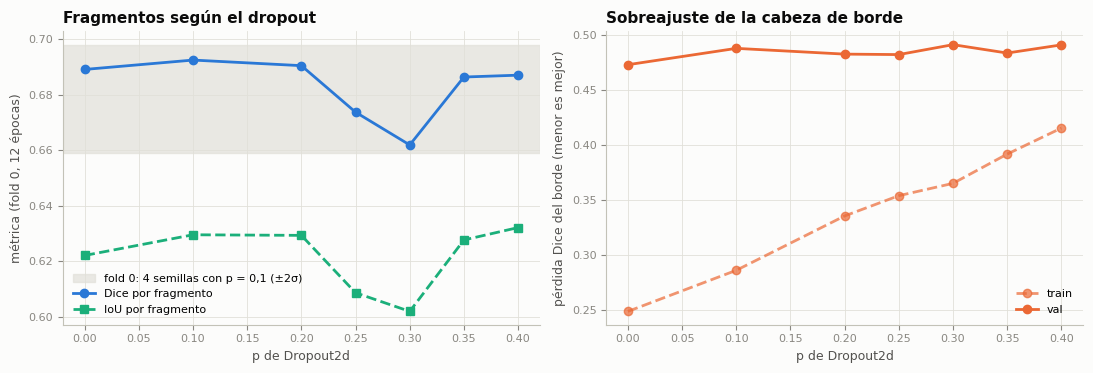

,"Δ Dice vs p = 0,1",Δ / σ semilla,dentro del rango de 4 semillas
p,,,
0.00,-0.0034,-0.3460,True
0.10,0.0000,0.0000,True
0.20,-0.0020,-0.2066,True
0.25,-0.0188,-1.9239,True
0.30,-0.0306,-3.1344,False
0.35,-0.0061,-0.6263,True
0.40,-0.0054,-0.5577,True


In [12]:
if not drop.empty and drop.p.max() >= 0.25:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    ax = axes[0]
    m, s = semillas["Dice frag"].mean(), SIGMA12
    ax.axhspan(m - 2 * s, m + 2 * s, color=GRID, alpha=0.7, label="fold 0: 4 semillas con p = 0,1 (±2σ)")
    d = drop.sort_values("p")
    ax.plot(d.p, d["Dice frag"], "o-", color=C["SA"], label="Dice por fragmento")
    ax.plot(d.p, d["IoU frag"], "s--", color=C["RI"], label="IoU por fragmento")
    ax.set(xlabel="p de Dropout2d", ylabel="métrica (fold 0, 12 épocas)")
    ax.set_title("Fragmentos según el dropout", loc="left")
    ax.legend()
    ax = axes[1]
    ax.plot(d.p, d["pérdida borde train"], "o--", color=C["LI"], alpha=0.7, label="train")
    ax.plot(d.p, d["pérdida borde val"], "o-", color=C["LI"], label="val")
    ax.set(xlabel="p de Dropout2d", ylabel="pérdida Dice del borde (menor es mejor)")
    ax.set_title("Sobreajuste de la cabeza de borde", loc="left")
    ax.legend()
    fig.tight_layout()
    savefig(fig, "05_dropout")
    plt.show()

    ref01 = drop.set_index("p")["Dice frag"]
    res = pd.DataFrame({"Δ Dice vs p = 0,1": ref01 - ref01[0.1], "Δ / σ semilla": (ref01 - ref01[0.1]) / SIGMA12,
                        "dentro del rango de 4 semillas": ref01.between(semillas["Dice frag"].min(), semillas["Dice frag"].max())})
    display(res.round(4))

- **No hay tendencia.** El Dice baja en 0,25 y 0,30 (0,674 y 0,662) y vuelve a subir en 0,35 y 0,40 (0,686 y 0,687). Si el dropout tuviera efecto, la curva iría en una sola dirección.
- Casi todos los puntos caen dentro del rango de las 4 semillas con p = 0,1 (0,670 a 0,693). Solo 0,30 queda fuera (−3σ), pero 0,35 y 0,40 vuelven al rango: con un solo fold, lo más probable es que sea ruido.
- La brecha de la pérdida de borde entre train y val sí se cierra (de 0,22 con p = 0 a 0,08 con p = 0,40), pero porque **empeora el train** (0,25 → 0,42); la de validación se queda en 0,47-0,49. El dropout frena el aprendizaje del borde sin hacerlo generalizar mejor.
- **Se queda p = 0,1.** Entre 0 y 0,40 el dropout espacial no cambia de forma medible la segmentación de fragmentos; lo que sí mide el ruido es la semilla.

## 9. Ensamble y TTA: atacar la varianza

Si cambiar solo la semilla mueve la métrica más que cualquier ajuste, parte del error es **varianza**: cada entrenamiento se equivoca en sitios distintos. Se probaron dos formas de promediar, sin reentrenar nada:

- **Ensamble:** promediar P(borde) y votar la región de varios modelos ya entrenados (`scripts/ensemble_oof.py`). De 2 modelos (misma config, semillas 42 y 1337) y de 6 (base ×2, c05, sin TL ×2, sin CBAM).
- **TTA (test-time augmentation):** el **mismo** modelo predice cada corte 5 veces con cambios leves (escala 0,92 y 1,08, rotación ±8°, dentro de la aumentación con la que se entrenó), se deshace cada cambio y se promedian las probabilidades (`pengwin/inference/volume.py`). También una versión de 9 pasadas que suma traslaciones de ±4 %.

Cada uno se combina con el posproceso de siempre (`edt`) y con F2C2. Referencia: el mismo modelo de una sola pasada.

In [13]:
FILAS9 = [  # (nombre, archivo, referencia, filtro)
    ("Ensamble 2 semillas", "pp_ens2_base", "pp1_base_e20", None),
    ("Ensamble 2 semillas + F2C2", "pp_ens2_base_hmax", "pp1_base_e20", None),
    ("Ensamble 6 modelos", "pp_ens6_todos", "pp1_base_e20", None),
    ("Ensamble 6 modelos + F2C2", "pp_ens6_todos_hmax", "pp1_base_e20", None),
    ("TTA 5 (semilla 42)", "pp_tta_base", "pp1_base_e20", None),
    ("TTA 5 + F2C2 (semilla 42)", "pp_tta_base_hmax", "pp1_base_e20", None),
    ("TTA 5 (semilla 1337)", "pp_tta_s1337", "pp1_c00b_seed1337_e20", None),
    ("TTA 5 + F2C2 (semilla 1337)", "pp_tta_s1337_hmax", "pp1_c00b_seed1337_e20", None),
    ("TTA 9 (semilla 42)", "pp_tta9_base", "pp1_base_e20", None),
    ("TTA 9 + F2C2 (semilla 42)", "pp_tta9_base_hmax", "pp1_base_e20", None),
]
filas, P9 = {}, {}
for nombre, arch, refn, filtro in FILAS9:
    f, prm = mejor(arch, filtro=filtro)
    if f is None:
        continue
    r, _ = mejor(refn)
    P9[nombre] = f
    pr = pareado(f, r)
    filas[nombre] = {"Dice frag": f.dice_fragmento.mean(), "IoU frag": f.iou_fragmento.mean(),
                     "Dice principal": f.dice_principal.mean(), "Secundarios %": f["recuperados_secundarios_%"].mean(),
                     "Δ Dice": pr["Δ"], "t": pr["t"], "folds a favor": pr["folds a favor"],
                     "Δ IoU": pareado(f, r, "iou_fragmento")["Δ"], "Δ principal": pareado(f, r, "dice_principal")["Δ"],
                     "posproceso": ", ".join(f"{k}={v}" for k, v in prm.items())}
var = pd.DataFrame(filas).T
display(pd.concat([ref_row, var]).round(4).fillna(""))

,Dice frag,IoU frag,Dice principal,Secundarios %,Δ Dice,t,folds a favor,Δ IoU,Δ principal,posproceso
"Referencia (base, semilla 42)",0.7453,0.6828,0.9206,59.5101,,,,,,
Ensamble 2 semillas,0.7570,0.6934,0.9228,61.4025,0.0117,1.7466,3/5,0.0106,0.0022,"method=edt, seed_depth_mm=5.0, edge_threshold=0.1"
Ensamble 2 semillas + F2C2,0.7849,0.7092,0.9118,65.9283,0.0396,3.7664,5/5,0.0264,-0.0088,"method=edt_hmax, seed_depth_mm=5.0, edge_thres..."
Ensamble 6 modelos,0.7788,0.7182,0.9298,64.8976,0.0335,4.1894,5/5,0.0354,0.0092,"method=edt, seed_depth_mm=5.0, edge_threshold=0.1"
Ensamble 6 modelos + F2C2,0.7975,0.7245,0.9156,66.9368,0.0522,3.2847,5/5,0.0416,-0.005,"method=edt_hmax, seed_depth_mm=5.0, edge_thres..."
TTA 5 (semilla 42),0.7638,0.7009,0.9236,63.9577,0.0185,2.3477,4/5,0.018,0.003,"method=edt, seed_depth_mm=5.0, edge_threshold=0.1"
TTA 5 + F2C2 (semilla 42),0.7922,0.7167,0.9143,67.8980,0.0469,4.1337,5/5,0.0339,-0.0063,"method=edt_hmax, seed_depth_mm=5.0, edge_thres..."
TTA 5 (semilla 1337),0.7533,0.6919,0.9229,59.6907,0.0087,0.8448,3/5,0.0233,0.0255,"method=edt, seed_depth_mm=5.0, edge_threshold=0.1"
TTA 5 + F2C2 (semilla 1337),0.7812,0.7081,0.9134,65.6029,0.0366,3.6576,4/5,0.0394,0.016,"method=edt_hmax, seed_depth_mm=5.0, edge_thres..."
TTA 9 (semilla 42),0.7491,0.6871,0.9207,60.4306,0.0038,0.8605,3/5,0.0043,0.0001,"method=edt, seed_depth_mm=5.0, edge_threshold=0.1"


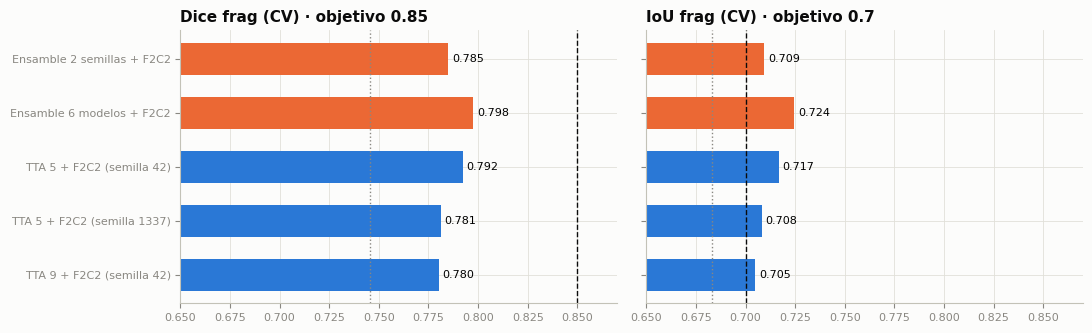

In [14]:
orden = ["Ensamble 2 semillas + F2C2", "Ensamble 6 modelos + F2C2", "TTA 5 + F2C2 (semilla 42)", "TTA 5 + F2C2 (semilla 1337)",
         "TTA 9 + F2C2 (semilla 42)"]
orden = [o for o in orden if o in var.index]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
y = np.arange(len(orden))[::-1]
for ax, col, obj in ((axes[0], "Dice frag", 0.85), (axes[1], "IoU frag", 0.70)):
    ref_v = ref_row[col].iloc[0]
    ax.barh(y, var.loc[orden, col].astype(float), color=[C["LI"] if "Ensamble" in o else C["SA"] for o in orden], height=0.6)
    ax.axvline(ref_v, color=MUTED, lw=1, ls=":")
    ax.axvline(obj, color=INK, lw=1, ls="--")
    ax.set_xlim(0.65, max(0.87, obj + 0.02))
    ax.set_title(f"{col} (CV) · objetivo {obj}", loc="left")
    for yi, v in zip(y, var.loc[orden, col].astype(float)):
        ax.text(v + 0.002, yi, f"{v:.3f}", va="center", fontsize=8)
axes[0].set_yticks(y, orden)
fig.tight_layout()
savefig(fig, "06_ensamble_tta")
plt.show()

- **Promediar sí ayuda, y es lo primero que se mueve por encima del ruido.** TTA de 5 pasadas + F2C2 sube el Dice +0,047 (t = 4,1, 5/5 folds) con la semilla 42 y +0,037 (4/5) con la 1337. El IoU pasa de 0,70 en las dos.
- **TTA es mejor que un ensamble de 2 modelos** (0,792 contra 0,785 de Dice) y casi iguala al de 6 (0,798). Promediar versiones del mismo modelo rinde lo mismo que entrenar más modelos.
- **El ensamble se descarta por el enunciado:** pide "tres cabezas sobre un mismo backbone", y un ensamble usa varios. TTA usa un solo modelo y no cambia la detección ni la clasificación.
- **TTA de 9 pasadas es peor que el de 5** (−0,012): las traslaciones emborronan el borde. Se queda el de 5.
- Con TTA, el Dice del fragmento principal baja poco (−0,006 con la semilla 42), dentro del límite de 0,010 que se había fijado para F2C2.

## 10. Modelo final

Configuración final, elegida solo con validación cruzada (`configs/tuned.yaml`):

- **Modelo:** `v2_last`, sin reentrenar. Arquitectura y entrenamiento iguales a `base.yaml` (FundidoraPC residual + CBAM en bloques 3-4 + 3 cabezas, dropout 0,1, con transfer learning).
- **Inferencia:** TTA de 5 pasadas (sección 9).
- **Posproceso:** `edt_hmax` (F2C2), profundidad 5 mm, umbral de borde 0,1, h = 1,5 mm.

F2C2 se adopta **después** de ver los datos: la regla fijada de antemano lo había dejado fuera por 0,0012 en una réplica. Se declara así. Con TTA cumple esa misma regla.

Se midió en test **una sola vez**. Como el IoU quedó a 0,003 del objetivo, después se intentó afinar por CV (sin volver a mirar el test) el posproceso con TTA. Resultados en la última tabla:

- `min_fragment_cm3` y `seed_min_cm3` no cambian nada: con `edt_hmax` no son los que generan los fragmentos de más.
- Profundidad 5,5 mm sube el Dice (+0,009 de media) pero el IoU casi no se mueve (+0,003: mejora con una semilla y empeora con la otra) y baja otra vez el principal. No se adopta.

Por eso no hubo segunda medición en test. (El barrido de `seed_min_cm3` se corrió en el PC local, con otras versiones de las librerías, y en el mismo punto da 0,002 menos que en ANTON.)

In [15]:
fin = REP / "fragments" / "v2_last_test_tuned.json"
antes = read_json(REP / "fragments" / "v2_last_test_edt.json")["global"]
if not fin.exists():
    print("Pendiente: la evaluación en test todavía no ha terminado.")
else:
    d = read_json(fin)
    g = d["global"]
    print("posproceso:", d.get("postproceso"), "· TTA:", d.get("tta"))
    filas = [("Clasificación", "F1", ev["cls_f1_macro"], ev["cls_f1_macro"], 0.85),
             ("Clasificación", "AUC", ev["cls_auc_macro"], ev["cls_auc_macro"], 0.85),
             ("Detección", "IoU promedio", ev["IoU_promedio"], ev["IoU_promedio"], 0.65),
             ("Detección", "mAP@0.50", ev["mAP@0.50"], ev["mAP@0.50"], 0.65),
             ("Detección", "mAP@[.50:.95]", ev["mAP@[.50:.95]"], ev["mAP@[.50:.95]"], 0.40),
             ("Fragmento", "Dice", antes["dice_fragmento"], g["dice_fragmento"], 0.85),
             ("Fragmento", "IoU", antes["iou_fragmento"], g["iou_fragmento"], 0.70),
             ("Fragmento", "Dice principal", antes["dice_principal"], g["dice_principal"], np.nan),
             ("Fragmento", "Dice secundario", antes["dice_secundario"], g["dice_secundario"], np.nan),
             ("Fragmento", "Secundarios recuperados %", antes["recuperados_secundarios_%"], g["recuperados_secundarios_%"], np.nan)]
    final = pd.DataFrame(filas, columns=["Tarea", "Métrica", "Antes (semana 10)", "Final", "Objetivo"])
    final["Cumple"] = np.where(final.Objetivo.isna(), "", np.where(final.Final >= final.Objetivo, "sí", "no"))
    display(final.round(3).fillna(""))

posproceso: {'instance_method': 'edt_hmax', 'edge_threshold': 0.1, 'min_fragment_cm3': 0.1, 'max_fragments': 10, 'seed_depth_mm': 5.0, 'seed_min_cm3': 0.02, 'edge_weight': 5.0, 'core_threshold': 0.5, 'core_seed_depth_mm': 0.0, 'hmax_h_mm': 1.5, 'dist_max_mm': 8.0} · TTA: 5


,Tarea,Métrica,Antes (semana 10),Final,Objetivo,Cumple
0,Clasificación,F1,0.993,0.993,0.85,sí
1,Clasificación,AUC,0.999,0.999,0.85,sí
2,Detección,IoU promedio,0.919,0.919,0.65,sí
3,Detección,mAP@0.50,0.980,0.980,0.65,sí
4,Detección,mAP@[.50:.95],0.864,0.864,0.4,sí
5,Fragmento,Dice,0.725,0.768,0.85,no
6,Fragmento,IoU,0.671,0.697,0.7,no
7,Fragmento,Dice principal,0.930,0.924,,
8,Fragmento,Dice secundario,0.489,0.588,,
9,Fragmento,Secundarios recuperados %,51.282,56.410,,


In [16]:
lat = {"sin TTA": REP / "latency" / "v2_last.json", "con TTA (final)": REP / "latency" / "v2_last_tta.json"}
filas = {}
for k, f in lat.items():
    if f.exists():
        l = read_json(f)
        filas[k] = {"CPU fp32 (ms/corte)": l["cpu_fp32"]["media_ms"], "GPU fp32 (ms/corte)": l["gpu_fp32"]["media_ms"],
                    "GPU AMP (ms/corte)": l["gpu_amp"]["media_ms"], "volumen completo GPU (s)": l["gpu_volumen_completo_s"],
                    "cortes": l["cortes_volumen"], "GPU": l["gpu"]}
pd.DataFrame(filas).T.round(1)

,CPU fp32 (ms/corte),GPU fp32 (ms/corte),GPU AMP (ms/corte),volumen completo GPU (s),cortes,GPU
sin TTA,66.1853,7.7102,10.3432,2.7568,401,NVIDIA GeForce RTX 3060 Laptop GPU
con TTA (final),308.6487,33.7952,37.9243,7.4084,401,NVIDIA GeForce RTX 3060 Laptop GPU


In [17]:
# Intentos de afinar el posproceso con TTA por CV (sin mirar el test): IoU por fragmento, media de 5 folds
fin_cv = []
for t, sem in (("base", 42), ("s1337", 1337)):
    for arch, k in ((f"pp_tta_{t}_fino", "seed_depth_mm"), (f"pp_tta_{t}_fino", "min_fragment_cm3"), (f"pp_tta_{t}_seedmin", "seed_min_cm3")):
        d = pp(arch)
        if d is None:
            continue
        if "fino" in arch:
            d = d[d.hmax_h_mm == 1.5]
            d = d[d.min_fragment_cm3 == 0.1] if k == "seed_depth_mm" else d[d.seed_depth_mm == 5.0]
        for v, g in d.groupby(k):
            fin_cv.append({"semilla": sem, "parámetro": k, "valor": v, "Dice frag": g.dice_fragmento.mean(), "IoU frag": g.iou_fragmento.mean()})
pd.DataFrame(fin_cv).set_index(["parámetro", "valor", "semilla"]).unstack("semilla").round(4)

Dice frag         IoU frag        
semilla                     42      1337     42      1337
parámetro        valor                                   
min_fragment_cm3 0.10     0.7922  0.7812   0.7167  0.7081
                 0.50     0.7922  0.7812   0.7167  0.7081
                 1.00     0.7922  0.7812   0.7167  0.7081
seed_depth_mm    4.50     0.7694  0.7713   0.7020  0.7043
                 5.00     0.7922  0.7812   0.7167  0.7081
                 5.50     0.7953  0.7957   0.7150  0.7152
seed_min_cm3     0.02     0.7903  0.7792   0.7149  0.7063
                 0.05     0.7902  0.7792   0.7149  0.7063
                 0.10     0.7902  0.7792   0.7148  0.7063
                 0.20     0.7902  0.7787   0.7148  0.7060
                 0.50     0.7892  0.7770   0.7141  0.7044

## 11. Conclusiones y siguiente paso

**Resultado.** Con el mismo modelo, cambiando solo la inferencia, el test pasa de Dice 0,725 a 0,768 y de IoU 0,671 a 0,697. Detección y clasificación siguen cumpliendo con amplio margen. El IoU por fragmento queda a 0,003 del objetivo y el Dice a 0,082.

**Qué aprendimos:**
1. **El cuello de botella es la cabeza de borde.** Encuentra menos del 20 % de la superficie de fractura. Con el borde real, el Dice sería 0,90 y se cumpliría todo.
2. **Los hiperparámetros no lo mueven.** Once candidatos, el dropout de 0 a 0,40, sin CBAM y sin TL: todo cae dentro del ruido de la semilla. Dos representaciones nuevas del borde (núcleo/borde y mapa de distancia) empeoraron.
3. **Lo que sí funcionó fue reducir la varianza** (TTA) y no perder semillas de fragmentos pequeños (F2C2). Juntos dan +0,04 en CV y en test.
4. **Medir el ruido primero evitó adoptar mejoras falsas.** Varias "mejoras" de 1 o 2 folds desaparecieron al repetir con otra semilla.

**Limitaciones para el model card:**
- El modelo predice más fragmentos de los reales (14 a 28 por paciente en test, contra 4 a 8 reales; el tope es 10 por hueso). La métrica por fragmento real no los castiga, pero en un uso real confundirían.
- Los fragmentos en contacto se siguen fusionando: el error de la distancia es 2,3 mm en los que están en contacto contra 0,7 mm en los separados.
- TTA multiplica la latencia por 4 a 5: 34-38 ms por corte en GPU y 309 ms en CPU (RTX 3060 Laptop), y 7,4 s un volumen de 401 cortes.

**Siguiente paso, si hubiera tiempo:** mejorar el borde de raíz, por ejemplo segmentando cada hueso recortado a mayor resolución en una segunda etapa (la lógica de dos etapas del challenge). Choca con la resolución recomendada de 224-256 px por corte, así que habría que justificarlo en el informe.

Comandos de la configuración final:

```powershell
python scripts/evaluate_fragments.py --ckpt checkpoints/v2_last/best.pth --cache-dir D:/PENGWIN/data_processed --data-dir D:/PENGWIN/01_data --split test --config configs/tuned.yaml --tag _tuned
python scripts/latency.py --ckpt checkpoints/v2_last/best.pth --cache-dir D:/PENGWIN/data_processed --tta
python scripts/consolidar_ajuste.py
```